Upload Source Image (for cropping)


Saving image.png to image (1).png
Upload Destination Image (for pasting)


Saving image 3.png to image 3.png
Cropped Image


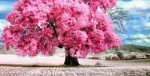

Final Image After Pasting


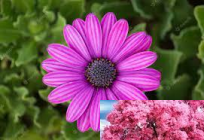

In [2]:
# ==========================================
# Cropping, Copying and Pasting using OpenCV
# Google Colab - Single Cell
# ==========================================

import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Step 1: Upload Two Images
print("Upload Source Image (for cropping)")
uploaded1 = files.upload()
source_path = list(uploaded1.keys())[0]

print("Upload Destination Image (for pasting)")
uploaded2 = files.upload()
dest_path = list(uploaded2.keys())[0]

# Step 2: Read Images
source = cv2.imread(source_path)
destination = cv2.imread(dest_path)

# Step 3: Crop Region from Source Image
# (y1:y2, x1:x2)
crop = source[50:200, 50:200]   # You can change coordinates

print("Cropped Image")
cv2_imshow(crop)

# Step 4: Copy and Paste into Destination Image
h_crop, w_crop = crop.shape[:2]

# Define paste position
paste_y, paste_x = 100, 100

# Calculate the actual region to paste into, considering image boundaries
# Determine the maximum height and width that can be pasted without exceeding destination dimensions
max_h_paste = min(h_crop, destination.shape[0] - paste_y)
max_w_paste = min(w_crop, destination.shape[1] - paste_x)

if max_h_paste <= 0 or max_w_paste <= 0:
    print("Error: The paste coordinates are out of bounds or the destination image is too small for the cropped image at these coordinates.")
else:
    # Ensure the crop itself is also trimmed if it's larger than the available paste area
    crop_to_paste = crop[:max_h_paste, :max_w_paste]

    # Paste the (potentially trimmed) crop into the destination
    destination[paste_y : paste_y + max_h_paste, paste_x : paste_x + max_w_paste] = crop_to_paste

    print("Final Image After Pasting")
    cv2_imshow(destination)
